### MDUS サンプルコード
MDUSの使用方法のサンプルコードです

#### 0. 利用準備
MDUSはデータを利用する際には手動でPDSからデータのダウンロードをする必要があります．事前に対応するデータをダウンロードしてください

ダウンロードが完了したら，MDUSディレクトリ内にある```setting.json```ファイル内の```ofile_path```にダウンロードしたデータファイルのパスを記載してください

また，MDUSはデータをバイナリー形式に変換します．
```pfile_path```に，変換したファイルのパスを記載してください

In [ ]:
{
    "MAG":{
        "name":"mag",
        "pfile_path":"/home/stream/data/mag/pfile",　<- バイナリーファイルの置き場．事前にディレクトリを作成しておく
        "ofile_path":"/home/stream/data/mag/ofile",　<- 元データの置き場．このディレクトリ内にダウロードしたファイルをおいておく
        "format":"MAGMSOSCIAVG" <- いじらない
    }
}

#### 1. 利用方法
磁場データを利用する場合，```MDUS.MagData```オブジェクトを作成した後，データのロードを行います．

適切な設定を行ったうえで，データをロードすることによって目的の期間のデータがダウンロード可能です．

データのロードの際には，時刻の直接指定と軌道番号からの指定の二通りが利用可能です．
なお，軌道番号は（論文名）のデータから引用しています

In [12]:
import MDUS

# MagDataオブジェクトの作成
data = MDUS.MagData()

# ロードする磁場データの設定
# e.g. 10秒値のデータをロード
data.Setting(sec=10)

# データのロード
# 1．時刻の直接指定
data.LoadData(start='2011/06/25 21:36:20',end='2011/06/25 22:16:20')
# 2. 軌道番号の指定
data.LoadData(orbit=199)

バイナリーファイルが作成されていない初回は以下のようなメッセージとともに，バイナリーへの変換が行われます．この際，オリジナルのデータは改変されることはありません．
```
Error: /home/stream/main/MDUS_Develop/2011_176_01.pkl is not found
Found original file. Convert to pickle file
```

データのロードに失敗した場合には以下のようなメッセージが表示されます
```
Error: There is no data file. Please download from PDS.
```

ロードしたデータの情報はInfoメソッドで確認可能です

In [2]:
# 情報の確認
data.Info()

Data Type
	MAG
Second
	10
unit
	Rm
Start Date
	2011-06-25 21:16:20
End Date
	2011-06-25 22:45:38
Original File
	/home/stream/main/152_181_JUN/MAGMSOSCIAVG11176_10_V08.TAB
Input File
	/home/stream/main/MDUS_Develop/2011_176_10.pkl
Orbit
	199


データはvalueに格納されています．
データはpandasのDataFrame形式で格納されているため，pandasのメソッドの利用が可能です

In [13]:
# 要素へのアクセス
data_value = data.value
# pandasのメソッドの利用
# e.g. queryの利用
data_value = data.value.query('X_MSO <= 0')

data_value

,X_MSO,Y_MSO,Z_MSO,Bx,By,Bz,|B|
date,,,,,,,
2011-06-25 21:31:20,-0.004783,0.143432,1.150359,78.414,-98.337,-373.054,393.685417
2011-06-25 21:31:30,-0.018261,0.137328,1.147868,85.605,-95.092,-377.916,398.987729
2011-06-25 21:31:40,-0.031738,0.131210,1.145265,92.051,-91.496,-381.804,403.260709
2011-06-25 21:31:50,-0.045211,0.125079,1.142548,99.123,-87.754,-386.286,408.341778
2011-06-25 21:32:00,-0.058680,0.118937,1.139718,107.144,-83.871,-390.538,413.562705
...,...,...,...,...,...,...,...
2011-06-25 22:44:50,-1.329784,-0.929744,-2.893161,25.149,-22.090,10.392,35.049022
2011-06-25 22:45:00,-1.327668,-0.929722,-2.900230,25.435,-18.154,11.044,33.143278
2011-06-25 22:45:10,-1.325547,-0.929695,-2.907287,24.517,-6.128,7.807,26.449668


簡易的なプロットを行うこともできます

磁場データのプロットと軌道データのプロットが可能になっています

いずれもpyplotを用いているため，pyplotと同様の操作も可能です

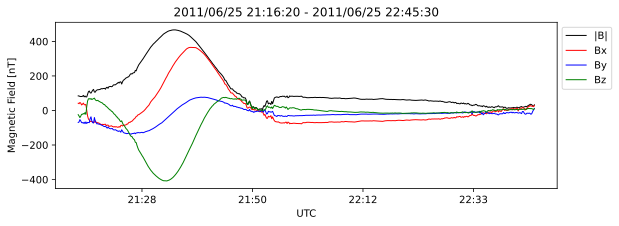

In [4]:
# 磁場データのプロット
fig, ax = data.Plot()

In [5]:
data.value

,X_MSO,Y_MSO,Z_MSO,Bx,By,Bz,|B|
date,,,,,,,
2011-06-25 21:16:20,1.110545,0.607811,1.024839,42.126,-69.321,-24.316,84.683344
2011-06-25 21:16:30,1.099756,0.603659,1.028846,39.206,-66.746,-32.042,83.778450
2011-06-25 21:16:40,1.088927,0.599487,1.032816,46.391,-52.964,-41.240,81.596861
2011-06-25 21:16:50,1.078059,0.595292,1.036749,42.034,-60.687,-32.679,80.732188
2011-06-25 21:17:00,1.067152,0.591077,1.040644,32.114,-70.856,-22.064,80.862240
...,...,...,...,...,...,...,...
2011-06-25 22:44:50,-1.329784,-0.929744,-2.893161,25.149,-22.090,10.392,35.049022
2011-06-25 22:45:00,-1.327668,-0.929722,-2.900230,25.435,-18.154,11.044,33.143278
2011-06-25 22:45:10,-1.325547,-0.929695,-2.907287,24.517,-6.128,7.807,26.449668


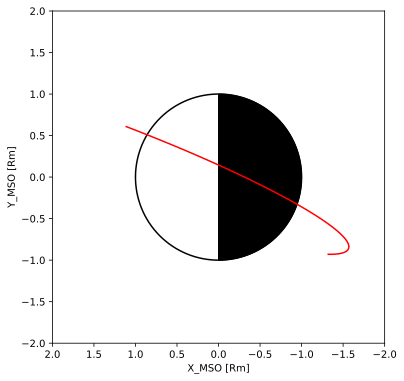

In [7]:
# 軌道データのプロット
# XY平面，MSO座標系の場合
fig, ax = data.PlotOrbit(plane='XY',coordinate='MSO')

座標変換も可能です．磁場データにはMSO座標が基本として入っていますが，
MSM座標系，aMSM座標系，MLAT等に変換可能です

In [ ]:
# aMSMへ変換する場合
data.CTransform('aMSM')
data.value

,X_MSO,Y_MSO,Z_MSO,Bx,By,Bz,|B|,X_aMSM,Y_aMSM,Z_aMSM
date,,,,,,,,,,
2011-06-25 21:16:20,1.110545,0.607811,1.024839,42.126,-69.321,-24.316,84.683344,1.179980,0.458685,0.824839
2011-06-25 21:16:30,1.099756,0.603659,1.028846,39.206,-66.746,-32.042,83.778450,1.168744,0.455967,0.828846
2011-06-25 21:16:40,1.088927,0.599487,1.032816,46.391,-52.964,-41.240,81.596861,1.157465,0.453234,0.832816
2011-06-25 21:16:50,1.078059,0.595292,1.036749,42.034,-60.687,-32.679,80.732188,1.146145,0.450484,0.836749
2011-06-25 21:17:00,1.067152,0.591077,1.040644,32.114,-70.856,-22.064,80.862240,1.134784,0.447718,0.840644
...,...,...,...,...,...,...,...,...,...,...
2011-06-25 22:44:50,-1.329784,-0.929744,-2.893161,25.149,-22.090,10.392,35.049022,-1.439111,-0.749473,-3.093161
2011-06-25 22:45:00,-1.327668,-0.929722,-2.900230,25.435,-18.154,11.044,33.143278,-1.437010,-0.749725,-3.100230
2011-06-25 22:45:10,-1.325547,-0.929695,-2.907287,24.517,-6.128,7.807,26.449668,-1.434903,-0.749974,-3.107287


In [14]:
# MCOORに変換する場合（MSO座標系を消去）
data.CTransform('MCOOR',replace=True)
data.value

,R_MSM,MLAT,MLON,MLT,Bx,By,Bz,|B|
date,,,,,,,,
2011-06-25 21:16:20,1.510995,33.085608,28.692279,13.912819,42.126,-69.321,-24.316,84.683344
2011-06-25 21:16:30,1.503613,33.451851,28.762526,13.917502,39.206,-66.746,-32.042,83.778450
2011-06-25 21:16:40,1.496238,33.821447,28.834107,13.922274,46.391,-52.964,-41.240,81.596861
2011-06-25 21:16:50,1.488869,34.194416,28.907007,13.927134,42.034,-60.687,-32.679,80.732188
2011-06-25 21:17:00,1.481509,34.570804,28.981314,13.932088,32.114,-70.856,-22.064,80.862240
...,...,...,...,...,...,...,...,...
2011-06-25 22:44:50,3.492907,-62.319912,214.960067,2.330671,25.149,-22.090,10.392,35.049022
2011-06-25 22:45:00,3.498358,-62.399020,215.002271,2.333485,25.435,-18.154,11.044,33.143278
2011-06-25 22:45:10,3.503803,-62.477874,215.044568,2.336305,24.517,-6.128,7.807,26.449668
